# IF3170 Artificial Intelligence | Tugas Besar 2


Group Number: 12

Group Members:
- Surya Suharna (18223075)
- Muhammad Aymar Barkhaya (18223051)
- Ni Made Sekar Jelita Parameswari (18223101)
- Muhammad Azzam Robbani (18223025)


## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif, f_classif, chi2
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix, 
                            classification_report, roc_curve, auc)
import warnings
import missingno as msno
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

All libraries imported successfully!


## Import Dataset

In [3]:
# Import dataset
import os
print("Current working directory:", os.getcwd())

# Try to load data from data directory
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print("Train dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)
print("\n=== Data Overview ===")
print(f"Training samples: {len(train_df):,}")
print(f"Test samples: {len(test_df):,}")
print(f"Number of features: {train_df.shape[1] - 1}")
print(f"\nTarget distribution:")
print(train_df['is_fraud'].value_counts())
print(f"Fraud percentage: {train_df['is_fraud'].mean()*100:.2f}%")

Current working directory: d:\Surya File\Institut Teknologi Bandung\Semester 5\Dasar AI\Final M2\RestInPeaceMom_Tugas-Besar-2-IF3070-2025\src
Train dataset shape: (100000, 31)
Test dataset shape: (100000, 30)

=== Data Overview ===
Training samples: 100,000
Test samples: 100,000
Number of features: 30

Target distribution:
is_fraud
0    85872
1    14128
Name: count, dtype: int64
Fraud percentage: 14.13%


In [4]:
# Display basic information
print("=== Training Data Info ===")
print(train_df.info())
print("\n=== Training Data Description ===")
print(train_df.describe())
print("\n=== Missing Values ===")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

=== Training Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID                      100000 non-null  int64  
 1   transaction_id          100000 non-null  object 
 2   user_id                 100000 non-null  int64  
 3   age                     100000 non-null  int64  
 4   gender                  100000 non-null  object 
 5   country                 100000 non-null  object 
 6   device_type             100000 non-null  object 
 7   device_os               100000 non-null  object 
 8   merchant_category       100000 non-null  object 
 9   transaction_amount      97581 non-null   float64
 10  transaction_type        100000 non-null  object 
 11  time_of_day             100000 non-null  int64  
 12  day_of_week             100000 non-null  int64  
 13  transaction_duration    100000 non-null  float64

# Exploratory Data Analysis (Optional)

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining and visualizing data sets to uncover patterns, trends, anomalies, and insights. It is the first step before applying more advanced statistical and machine learning techniques. EDA helps you to gain a deep understanding of the data you are working with, allowing you to make informed decisions and formulate hypotheses for further analysis.

## Inspecting Data

In [5]:
# Check Data Size
print(f"Jumlah baris: {train_df.shape[0]}, Jumlah kolom: {train_df.shape[1]}")

Jumlah baris: 100000, Jumlah kolom: 31


In [6]:
# Identify Data Types
print(train_df.dtypes)

ID                          int64
transaction_id             object
user_id                     int64
age                         int64
gender                     object
country                    object
device_type                object
device_os                  object
merchant_category          object
transaction_amount        float64
transaction_type           object
time_of_day                 int64
day_of_week                 int64
transaction_duration      float64
num_prev_transactions       int64
avg_transaction_amount    float64
std_transaction_amount    float64
transactions_last_24h       int64
transactions_last_1h        int64
failed_login_attempts       int64
ip_risk_score             float64
device_trust_score        float64
account_age_days            int64
has_chargeback_history      int64
shared_ip_users             int64
shared_device_users         int64
merchant_risk             float64
country_risk              float64
distance_from_home        float64
is_new_country


Features with missing values:


['transaction_amount', 'avg_transaction_amount', 'device_trust_score']

Total count of missing values in the dataset:
7257

Total Count of missing values per feature:
ID                           0
transaction_id               0
user_id                      0
age                          0
gender                       0
country                      0
device_type                  0
device_os                    0
merchant_category            0
transaction_amount        2419
transaction_type             0
time_of_day                  0
day_of_week                  0
transaction_duration         0
num_prev_transactions        0
avg_transaction_amount    2419
std_transaction_amount       0
transactions_last_24h        0
transactions_last_1h         0
failed_login_attempts        0
ip_risk_score                0
device_trust_score        2419
account_age_days             0
has_chargeback_history       0
shared_ip_users              0
shared_device_users          0
merchant_risk              

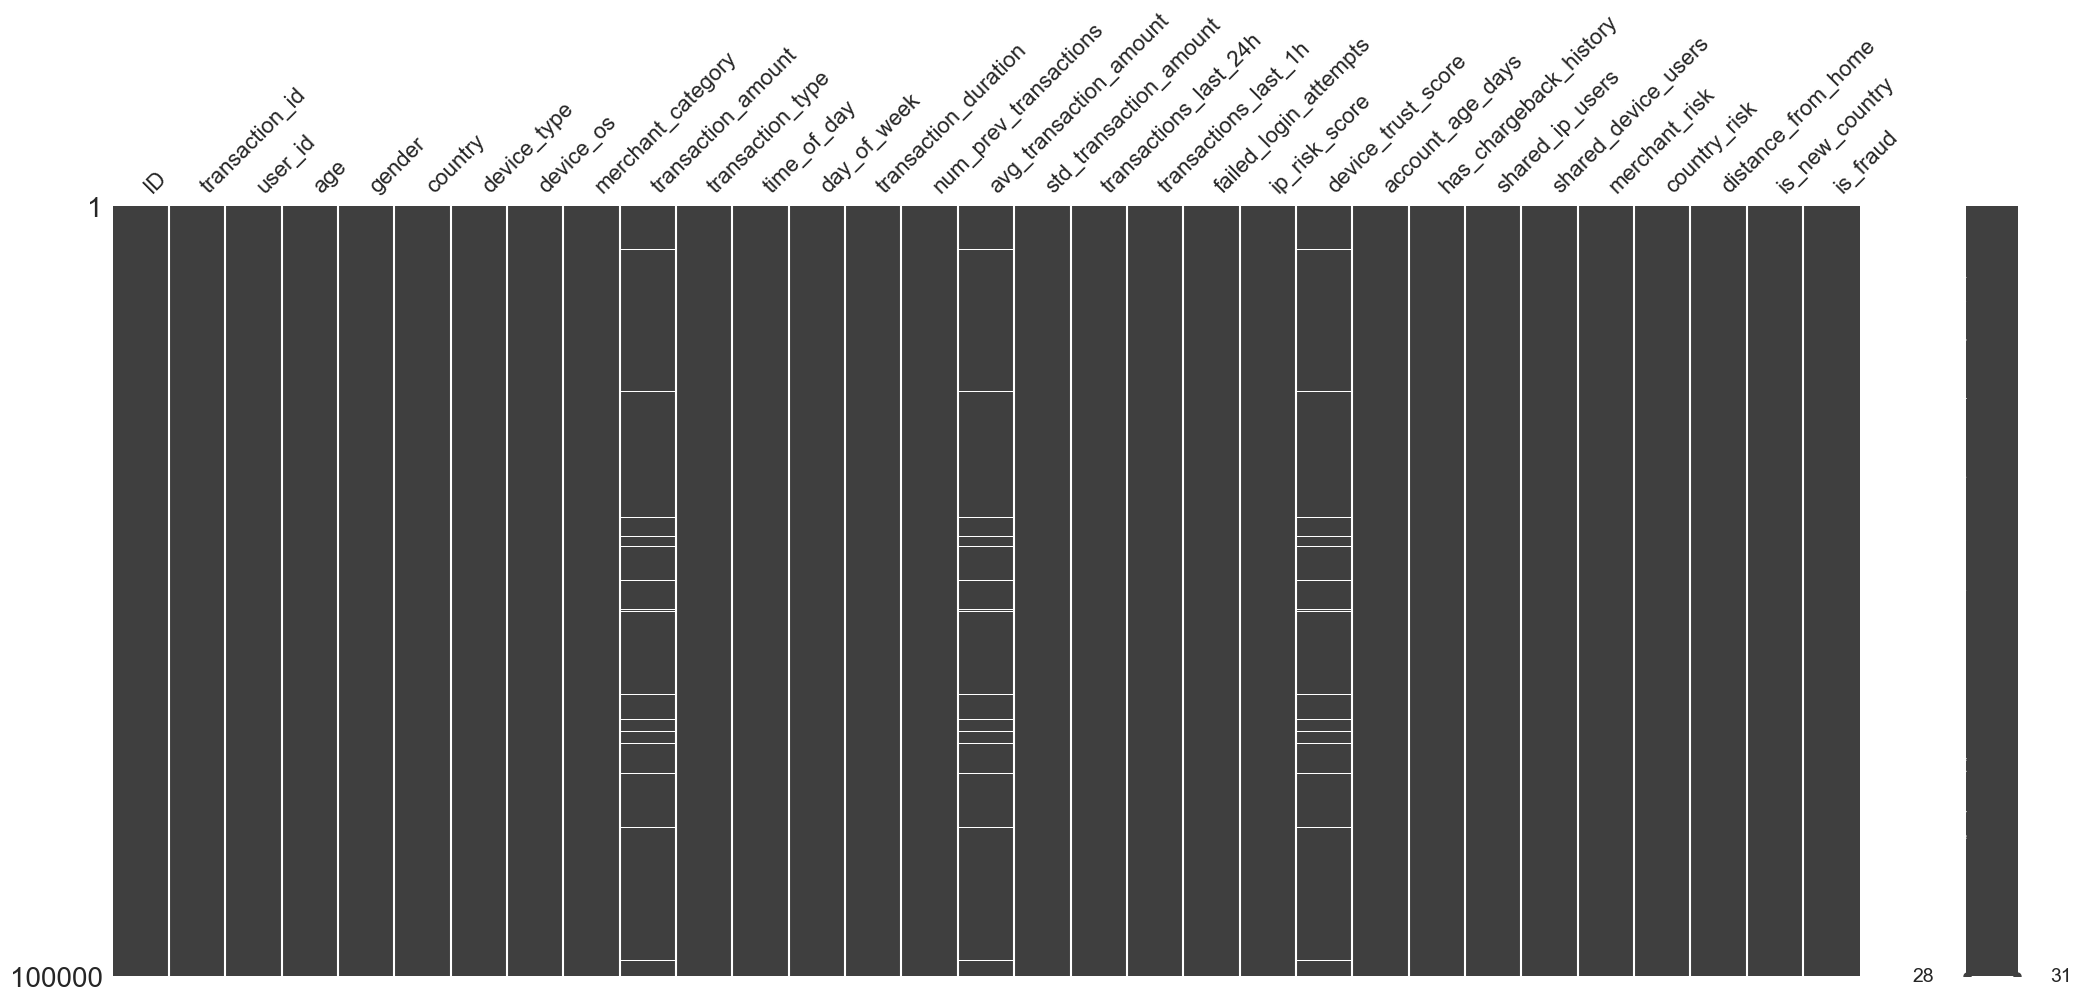

In [7]:
# Which feature has missing values?
print("\nFeatures with missing values:")
print([col for col in train_df.columns if train_df[col].isnull().any()])

print("\nTotal count of missing values in the dataset:")
print(train_df.isnull().values.sum())

print("\nTotal Count of missing values per feature:")
print(train_df.isna().sum())

# Visualize missing values
msno.matrix(train_df)
plt.show()

In [8]:
# Display basic information
print("=== Training Data Info ===")
print(train_df.info())


=== Training Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   ID                      100000 non-null  int64  
 1   transaction_id          100000 non-null  object 
 2   user_id                 100000 non-null  int64  
 3   age                     100000 non-null  int64  
 4   gender                  100000 non-null  object 
 5   country                 100000 non-null  object 
 6   device_type             100000 non-null  object 
 7   device_os               100000 non-null  object 
 8   merchant_category       100000 non-null  object 
 9   transaction_amount      97581 non-null   float64
 10  transaction_type        100000 non-null  object 
 11  time_of_day             100000 non-null  int64  
 12  day_of_week             100000 non-null  int64  
 13  transaction_duration    100000 non-null  float64

In [9]:
# Unique Values in Categorical Features

#Transaction Type
print("Transaction Type Description and Unique Values:")
transaction_type_desc = train_df["transaction_type"].describe()
unique_transtype = train_df['transaction_type'].unique()

print(transaction_type_desc)
print(unique_transtype)

# Device OS
print("\nDevice OS Description and Unique Values:")
deviceos_desc = train_df["device_os"].describe()
unique_deviceos = train_df['device_os'].unique()

print(deviceos_desc)
print(unique_deviceos)

# Device Type
print("\nDevice Type Description and Unique Values:")
devicetype_desc = train_df["device_type"].describe()
unique_devicetype = train_df['device_type'].unique()

print(devicetype_desc)
print(unique_devicetype)

Transaction Type Description and Unique Values:


count       100000
unique           4
top       purchase
freq         59395
Name: transaction_type, dtype: object
['purchase' 'topup' 'withdrawal' 'transfer']

Device OS Description and Unique Values:
count      100000
unique          5
top       Android
freq        49183
Name: device_os, dtype: object
['Android' 'iOS' 'Windows' 'Linux' 'MacOS']

Device Type Description and Unique Values:
count     100000
unique         3
top       mobile
freq       78292
Name: device_type, dtype: object
['mobile' 'desktop' 'tablet']


## Exploring Data Characteristics

In [10]:
print("=== Statistik Deskriptif untuk Data Numerik ===\n")
print(train_df.describe())

=== Statistik Deskriptif untuk Data Numerik ===

                  ID        user_id            age  transaction_amount  \
count  100000.000000  100000.000000  100000.000000        97581.000000   
mean    49999.500000   15040.173180      48.484150          126.855288   
std     28867.657797    8655.074007      17.892168          376.035544   
min         0.000000       1.000000      18.000000            0.010000   
25%     24999.750000    7549.000000      33.000000           26.910000   
50%     49999.500000   15093.000000      48.000000           64.460000   
75%     74999.250000   22541.000000      64.000000          131.060000   
max     99999.000000   29999.000000      79.000000        20601.133350   

         time_of_day    day_of_week  transaction_duration  \
count  100000.000000  100000.000000         100000.000000   
mean       12.770160       2.780700              3.999587   
std         5.748626       2.064754              4.012831   
min         0.000000       0.000000     

## Eksplorasi Data

In [11]:
# Summary Statistics of Numerical Features including Skewness and Kurtosis
summary = pd.DataFrame()

summary["min"] = train_df.min(numeric_only=True)
summary["max"] = train_df.max(numeric_only=True)
summary["mean"] = train_df.mean(numeric_only=True)
summary["median"] = train_df.median(numeric_only=True)
summary["mode"] = train_df.mode(numeric_only=True).iloc[0]
summary["std"] = train_df.std(numeric_only=True)
summary["skewness"] = train_df.skew(numeric_only=True)
summary["kurtosis"] = train_df.kurtosis(numeric_only=True)


summary

,min,max,mean,median,mode,std,skewness,kurtosis
ID,0.00,99999.000000,49999.500000,49999.500,0.000,28867.657797,0.000000,-1.200000
user_id,1.00,29999.000000,15040.173180,15093.000,18896.000,8655.074007,-0.007491,-1.197771
age,18.00,79.000000,48.484150,48.000,40.000,17.892168,0.002919,-1.195800
transaction_amount,0.01,20601.133350,126.855288,64.460,0.190,376.035544,14.793343,330.302199
time_of_day,0.00,23.000000,12.770160,12.000,18.000,5.748626,-0.184745,-1.021863
day_of_week,0.00,6.000000,2.780700,3.000,0.000,2.064754,0.066893,-1.375726
transaction_duration,0.00,52.070000,3.999587,2.760,0.140,4.012831,2.021264,6.248908
num_prev_transactions,8.00,59.000000,29.992080,30.000,29.000,5.486210,0.179529,0.030904
avg_transaction_amount,-52.89,195.790000,69.969722,69.990,84.350,29.961530,-0.000764,-0.034694
std_transaction_amount,5.00,80.000000,42.541209,42.480,47.350,21.652791,-0.000783,-1.198752


## Visualizing Relationship of Data

### Categorical Data

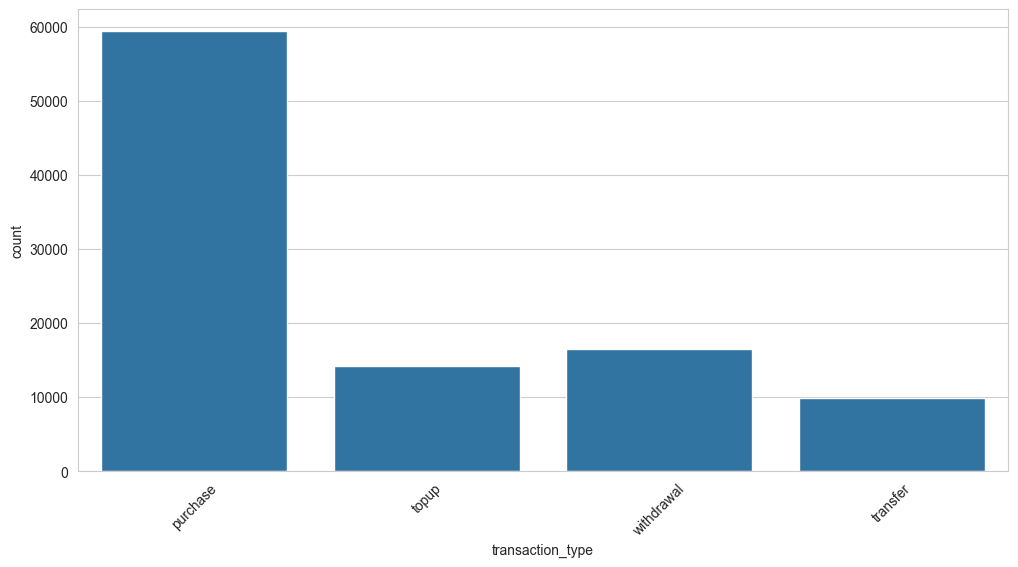

In [12]:
# Visualisasi Distribusi Kategori transaction_type
sns.countplot(data=train_df, x="transaction_type")
plt.xticks(rotation=45)
plt.show()

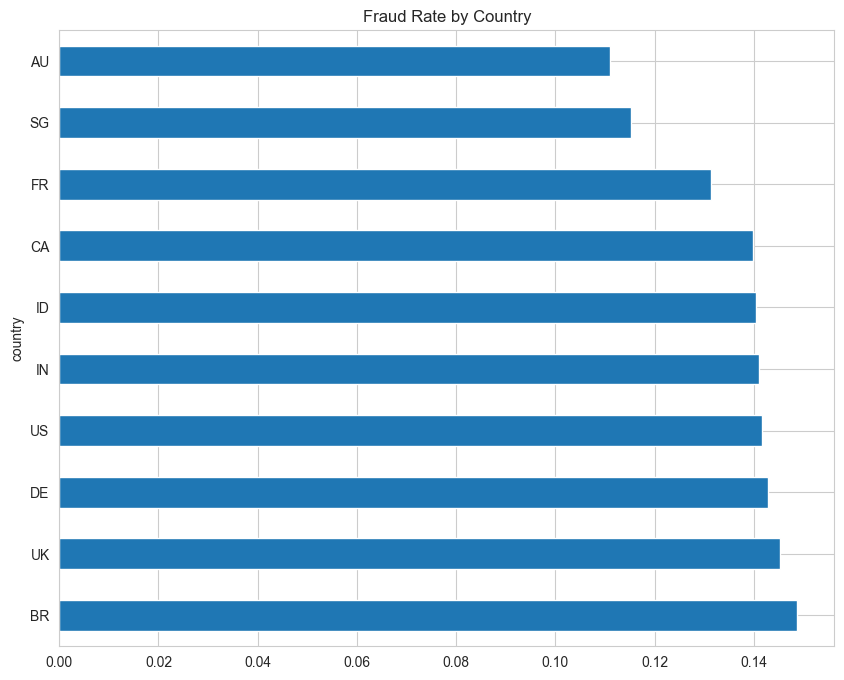

In [13]:
train_eda = train_df.copy()
(train_eda.groupby("country")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
    .plot(kind="barh", figsize=(10,8)))
plt.title("Fraud Rate by Country")
plt.show()

In [14]:
cat_cols = [col for col in train_df.columns 
            if train_df[col].dtype == 'object' or train_df[col].dtype.name == 'category']

#Unique values in categorical features
for col in cat_cols:
    print(col, train_df[col].nunique())

transaction_id 100000
gender 2
country 10
device_type 3
device_os 5
merchant_category 9
transaction_type 4


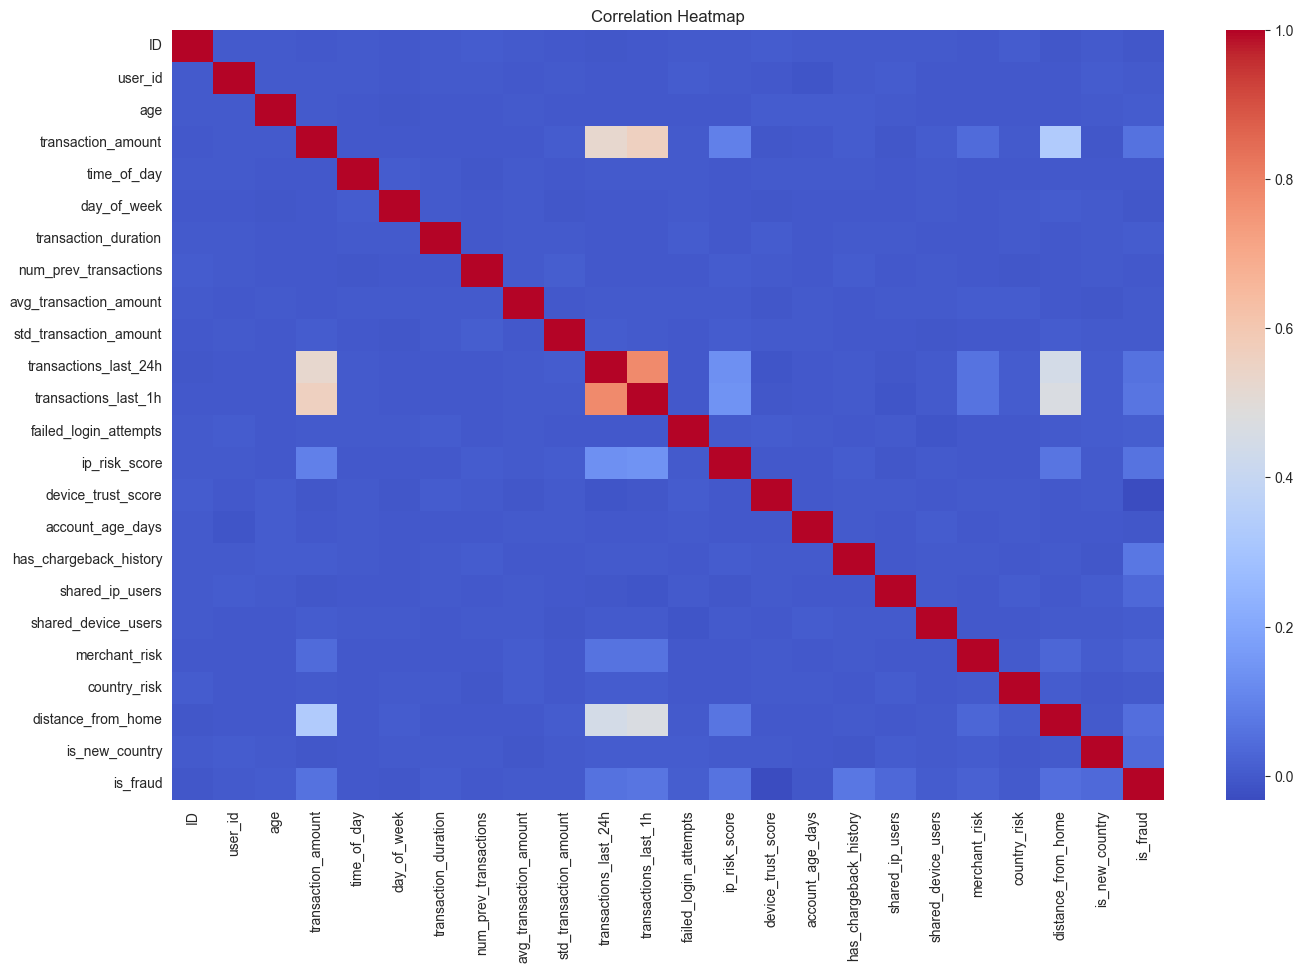

In [16]:
plt.figure(figsize=(16,10))
sns.heatmap(train_eda.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

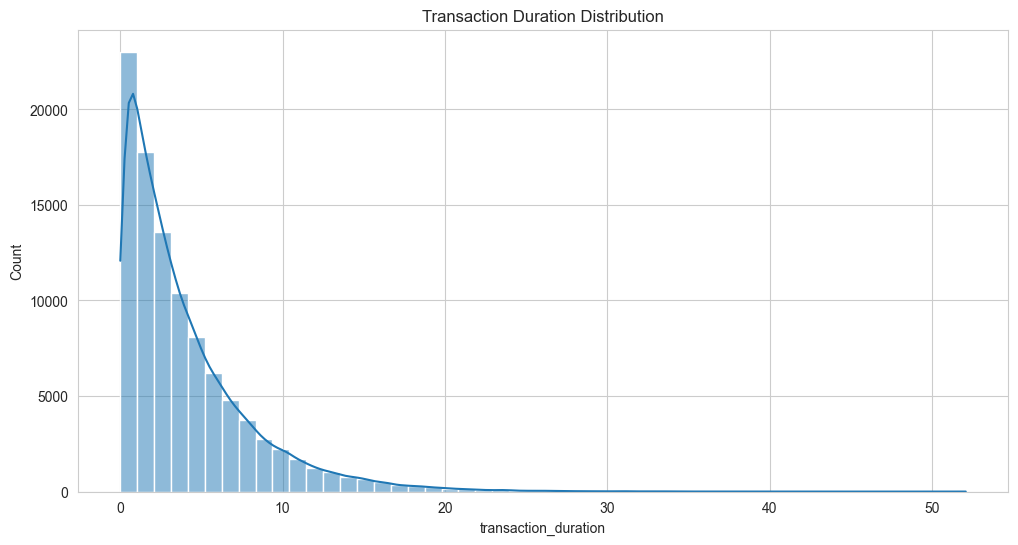

In [ ]:
sns.histplot(train_eda['transaction_duration'], bins=50, kde=True)
plt.title("Transaction Duration Distribution")
plt.show()

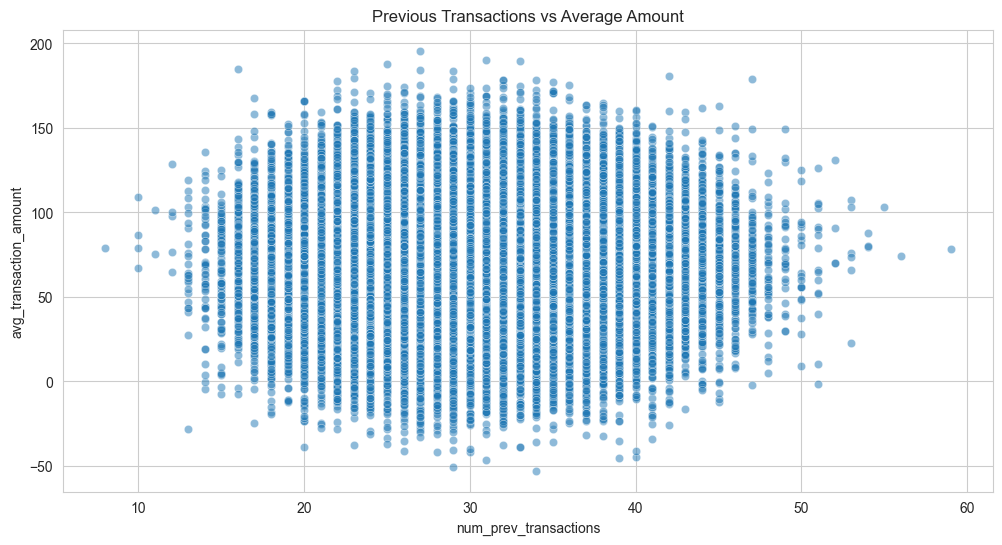

In [ ]:
sns.scatterplot(data=train_eda, x="num_prev_transactions", 
                y="avg_transaction_amount", alpha=0.5)
plt.title("Previous Transactions vs Average Amount")
plt.show()

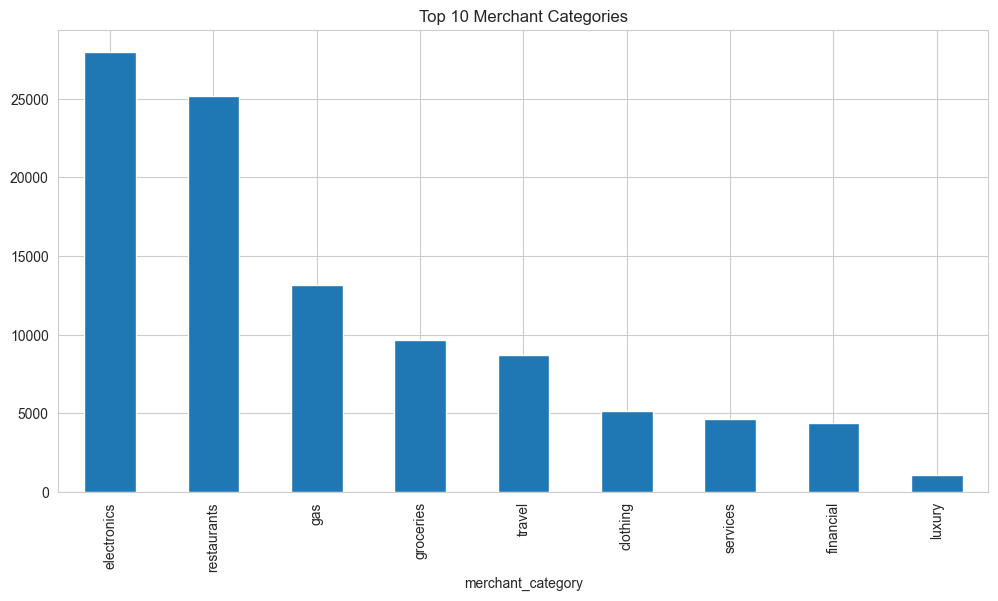

In [ ]:
train_eda["merchant_category"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Merchant Categories")
plt.show()


# 1. Split Training Set, Validation Set, Testing Set

Splitting the training and validation set works as an early diagnostic towards the performance of the model we train. This is done before the preprocessing steps to **avoid data leakage inbetween the sets**. If you want to use k-fold cross-validation, split the data later and do the cleaning and preprocessing separately for each split.

Note: For training, you should use the data contained in the `train` folder given by the TA. The `test` data is only used for kaggle submission.

In [17]:
raw_data = train_df.copy()
raw_train = train_df.copy()
X_test = test_df.copy()

In [18]:
# Separate features and target () train.csv
X_full = raw_train.drop('is_fraud', axis=1) # features
y_full = raw_train['is_fraud'] #target feature: is_fraud

In [19]:
# Separate features and target () train.csv yang akan di-split
X = raw_data.drop('is_fraud', axis=1) # features
y = raw_data['is_fraud'] #target feature: is_fraud

# Splitting training data into train set and val set
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# X_train 80% feature
# y_train 80% of target values
# X_val 20% feature
# y_val 20% of target values

print(f"Training set size: {len(X_train):,}")
print(f"Validation set size: {len(X_val):,}")
print(f"\nTraining set fraud rate: {y_train.mean()*100:.2f}%")
print(f"Validation set fraud rate: {y_val.mean()*100:.2f}%")

Training set size: 80,000
Validation set size: 20,000

Training set fraud rate: 14.13%
Validation set fraud rate: 14.13%


# 2. Data Cleaning and Preprocessing

This step is the first thing to be done once a Data Scientist have grasped a general knowledge of the data. Raw data is **seldom ready for training**, therefore steps need to be taken to clean and format the data for the Machine Learning model to interpret.

By performing data cleaning and preprocessing, you ensure that your dataset is ready for model training, leading to more accurate and reliable machine learning results. These steps are essential for transforming raw data into a format that machine learning algorithms can effectively learn from and make predictions.

We will give some common methods for you to try, but you only have to **at least implement one method for each process**. For each step that you will do, **please explain the reason why did you do that process. Write it in a markdown cell under the code cell you wrote.**

## A. Data Cleaning

**Data cleaning** is the crucial first step in preparing your dataset for machine learning. Raw data collected from various sources is often messy and may contain errors, missing values, and inconsistencies. Data cleaning involves the following steps:

1. **Handling Missing Data:** Identify and address missing values in the dataset. This can include imputing missing values, removing rows or columns with excessive missing data, or using more advanced techniques like interpolation.

2. **Dealing with Outliers:** Identify and handle outliers, which are data points significantly different from the rest of the dataset. Outliers can be removed or transformed to improve model performance.

3. **Data Validation:** Check for data integrity and consistency. Ensure that data types are correct, categorical variables have consistent labels, and numerical values fall within expected ranges.

4. **Removing Duplicates:** Identify and remove duplicate rows, as they can skew the model's training process and evaluation metrics.

5. **Feature Engineering**: Create new features or modify existing ones to extract relevant information. This step can involve scaling, normalizing, or encoding features for better model interpretability.

### 1. Handling Missing Data

Missing data can adversely affect the performance and accuracy of machine learning models. There are several strategies to handle missing data in machine learning:

1. **Data Imputation:**

    a. **Mean, Median, or Mode Imputation:** For numerical features, you can replace missing values with the mean, median, or mode of the non-missing values in the same feature. This method is simple and often effective when data is missing at random.

    b. **Constant Value Imputation:** You can replace missing values with a predefined constant value (e.g., 0) if it makes sense for your dataset and problem.

    c. **Imputation Using Predictive Models:** More advanced techniques involve using predictive models to estimate missing values. For example, you can train a regression model to predict missing numerical values or a classification model to predict missing categorical values.

2. **Deletion of Missing Data:**

    a. **Listwise Deletion:** In cases where the amount of missing data is relatively small, you can simply remove rows with missing values from your dataset. However, this approach can lead to a loss of valuable information.

    b. **Column (Feature) Deletion:** If a feature has a large number of missing values and is not critical for your analysis, you can consider removing that feature altogether.

3. **Domain-Specific Strategies:**

    a. **Domain Knowledge:** In some cases, domain knowledge can guide the imputation process. For example, if you know that missing values are related to a specific condition, you can impute them accordingly.

4. **Imputation Libraries:**

    a. **Scikit-Learn:** Scikit-Learn provides a `SimpleImputer` class that can handle basic imputation strategies like mean, median, and mode imputation.

    b. **Fancyimpute:** Fancyimpute is a Python library that offers more advanced imputation techniques, including matrix factorization, k-nearest neighbors, and deep learning-based methods.

The choice of imputation method should be guided by the nature of your data, the amount of missing data, the problem you are trying to solve, and the assumptions you are willing to make.

In [20]:
#Check all missing values

X_train.isnull().sum()

ID                           0
transaction_id               0
user_id                      0
age                          0
gender                       0
country                      0
device_type                  0
device_os                    0
merchant_category            0
transaction_amount        1920
transaction_type             0
time_of_day                  0
day_of_week                  0
transaction_duration         0
num_prev_transactions        0
avg_transaction_amount    1920
std_transaction_amount       0
transactions_last_24h        0
transactions_last_1h         0
failed_login_attempts        0
ip_risk_score                0
device_trust_score        1920
account_age_days             0
has_chargeback_history       0
shared_ip_users              0
shared_device_users          0
merchant_risk                0
country_risk                 0
distance_from_home           0
is_new_country               0
dtype: int64

In [21]:
X_val.isnull().sum()

ID                          0
transaction_id              0
user_id                     0
age                         0
gender                      0
country                     0
device_type                 0
device_os                   0
merchant_category           0
transaction_amount        499
transaction_type            0
time_of_day                 0
day_of_week                 0
transaction_duration        0
num_prev_transactions       0
avg_transaction_amount    499
std_transaction_amount      0
transactions_last_24h       0
transactions_last_1h        0
failed_login_attempts       0
ip_risk_score               0
device_trust_score        499
account_age_days            0
has_chargeback_history      0
shared_ip_users             0
shared_device_users         0
merchant_risk               0
country_risk                0
distance_from_home          0
is_new_country              0
dtype: int64

In [22]:
# Create flags for missing values
def create_null_flags(X):
    X = X.copy()
    X['device_trust_score_missing'] = X['device_trust_score'].isnull().astype(int)
    X['avg_transaction_amount_missing'] = X['avg_transaction_amount'].isnull().astype(int)
    X['transaction_amount_missing'] = X['transaction_amount'].isnull().astype(int)

    return X

X_full = create_null_flags(X_full)
X_train = create_null_flags(X_train)
X_val = create_null_flags(X_val)
X_test = create_null_flags(X_test)
print("Missing value flags created successfully!")

Missing value flags created successfully!


In [23]:
# Imputing median on the missing values
def impute_median(X):
    X = X.copy()
    X['transaction_amount'].fillna(X['transaction_amount'].median(), inplace=True)
    X['avg_transaction_amount'].fillna(X['avg_transaction_amount'].median(), inplace=True)
    X['device_trust_score'].fillna(X['device_trust_score'].median(), inplace=True)
    
    return X

X_full = impute_median(X_full)
X_train = impute_median(X_train)
X_val = impute_median(X_val)
X_test = impute_median(X_test)
print("Missing value imputed with median successfully!")

Missing value imputed with median successfully!


In [24]:
# Data sudah tidak memiliki nilai null lagi, yay!
X_train.isnull().sum()

ID                                0
transaction_id                    0
user_id                           0
age                               0
gender                            0
country                           0
device_type                       0
device_os                         0
merchant_category                 0
transaction_amount                0
transaction_type                  0
time_of_day                       0
day_of_week                       0
transaction_duration              0
num_prev_transactions             0
avg_transaction_amount            0
std_transaction_amount            0
transactions_last_24h             0
transactions_last_1h              0
failed_login_attempts             0
ip_risk_score                     0
device_trust_score                0
account_age_days                  0
has_chargeback_history            0
shared_ip_users                   0
shared_device_users               0
merchant_risk                     0
country_risk                

In [25]:
X_val.isnull().sum()

ID                                0
transaction_id                    0
user_id                           0
age                               0
gender                            0
country                           0
device_type                       0
device_os                         0
merchant_category                 0
transaction_amount                0
transaction_type                  0
time_of_day                       0
day_of_week                       0
transaction_duration              0
num_prev_transactions             0
avg_transaction_amount            0
std_transaction_amount            0
transactions_last_24h             0
transactions_last_1h              0
failed_login_attempts             0
ip_risk_score                     0
device_trust_score                0
account_age_days                  0
has_chargeback_history            0
shared_ip_users                   0
shared_device_users               0
merchant_risk                     0
country_risk                

The missing percentage is low, the skewness of transaction_amountis high, but the rest are normal. We use median imputation because the percentage of the missing values are small and it's also fast to compute.

Ada 3 kolom numerik yang memiliki data hilang, masing-masing sejumlah 2419 baris dari total 100.000, atau sekitar 2.419%:

*   transaction_amount
*   avg_transaction_amount
*   device_trust_score

The device_trust_score being missing might indicate fraud since the missing score might indicate that the users use incognito mode or similar method. Although, the other two features might just be a data processing error.

### 2. Dealing with Outliers

Outliers are data points that significantly differ from the majority of the data. They can be unusually high or low values that do not fit the pattern of the rest of the dataset. Outliers can significantly impact model performance, so it is important to handle them properly.

Some methods to handle outliers:
1. **Imputation**: Replace with mean, median, or a boundary value.
2. **Clipping**: Cap values to upper and lower limits.
3. **Transformation**: Use log, square root, or power transformations to reduce their influence.
4. **Model-Based**: Use algorithms robust to outliers (e.g., tree-based models, Huber regression).

Consideration on handling the outliers:
- The features that might represent user behavior, e.g. transaction_amount, device_trust_score
- The outliers could be the fraud cases

What must be removed: Invalid values and errors

In [26]:
def iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [27]:
def outlier_count(X):
    ta_lower_bound, ta_upper_bound = iqr(X, 'transaction_amount')
    avgta_lower_bound, avgta_upper_bound = iqr(X, 'avg_transaction_amount')
    tl24h_lower_bound, tl24h_upper_bound = iqr(X, 'transactions_last_24h')
    tl1h_lower_bound, tl1h_upper_bound = iqr(X, 'transactions_last_1h')
    td_lower_bound, td_upper_bound = iqr(X, 'transaction_duration')
    fla_lower_bound, fla_upper_bound = iqr(X, 'failed_login_attempts')
    agd_lower_bound, agd_upper_bound = iqr(X, 'account_age_days')
    dfh_lower_bound, dfh_upper_bound = iqr(X, 'distance_from_home')
    npt_lower_bound, npt_upper_bound = iqr(X, 'num_prev_transactions')

    ta_outliers = X[(X['transaction_amount'] < ta_lower_bound) | (X['transaction_amount'] > ta_upper_bound)]
    avgta_outliers = X[(X['avg_transaction_amount'] < avgta_lower_bound) | (X['avg_transaction_amount'] > avgta_upper_bound)]
    tl24h_outliers = X[(X['transactions_last_24h'] < tl24h_lower_bound) | (X['transactions_last_24h'] > tl24h_upper_bound)]
    tl1h_outliers = X[(X['transactions_last_1h'] < tl1h_lower_bound) | (X['transactions_last_1h'] > tl1h_upper_bound)]
    td_outliers = X[(X['transaction_duration'] < td_lower_bound) | (X['transaction_duration'] > td_upper_bound)]
    fla_outliers = X[(X['failed_login_attempts'] < fla_lower_bound) | (X['failed_login_attempts'] > fla_upper_bound)]
    agd_outliers = X[(X['account_age_days'] < agd_lower_bound) | (X['account_age_days'] > agd_upper_bound)]
    dfh_outliers = X[(X['distance_from_home'] < dfh_lower_bound) | (X['distance_from_home'] > dfh_upper_bound)]
    npt_outliers = X[(X['num_prev_transactions'] < npt_lower_bound) | (X['num_prev_transactions'] > npt_upper_bound)]

    print("Number of outliers in transaction_amount:", len(ta_outliers))
    print("Percentage of outliers in transaction_amount:", len(ta_outliers)/len(X) * 100, "%")

    print("\nNumber of outliers in avg_transaction_amount:", len(avgta_outliers))
    print("Percentage of outliers in avg_transaction_amount:", len(avgta_outliers)/len(X) * 100, "%")

    print("\nNumber of outliers in transactions_last_24h:", len(tl24h_outliers))
    print("Percentage of outliers in transactions_last_24h:", len(tl24h_outliers)/len(X) * 100, "%")

    print("\nNumber of outliers in transactions_last_1h:", len(tl1h_outliers))
    print("Percentage of outliers in transactions_last_1h:", len(tl1h_outliers)/len(X) * 100, "%")

    print("\nNumber of outliers in transaction_duration:", len(td_outliers))
    print("Percentage of outliers in transaction_duration:", len(td_outliers)/len(X) * 100, "%")

    print("\nNumber of outliers in failed_login_attempts:", len(fla_outliers))
    print("Percentage of outliers in failed_login_attempts:", len(fla_outliers)/len(X) * 100, "%")

    print("\nNumber of outliers in account_age_days:", len(agd_outliers))
    print("Percentage of outliers in account_age_days:", len(agd_outliers)/len(X) * 100, "%")

    print("\nNumber of outliers in distance_from_home:", len(dfh_outliers))
    print("Percentage of outliers in distance_from_home:", len(dfh_outliers)/len(X) * 100, "%")

    print("\nNumber of outliers in num_prev_transactions:", len(npt_outliers))
    print("Percentage of outliers in num_prev_transactions:", len(npt_outliers)/len(X) * 100, "%")

outlier_count(X_full)
# outlier_count(X_train)
# outlier_count(X_val)
# outlier_count(X_test)

Number of outliers in transaction_amount: 6247
Percentage of outliers in transaction_amount: 6.247 %

Number of outliers in avg_transaction_amount: 815
Percentage of outliers in avg_transaction_amount: 0.815 %

Number of outliers in transactions_last_24h: 8878
Percentage of outliers in transactions_last_24h: 8.878 %

Number of outliers in transactions_last_1h: 11697
Percentage of outliers in transactions_last_1h: 11.697000000000001 %

Number of outliers in transaction_duration: 4903
Percentage of outliers in transaction_duration: 4.903 %

Number of outliers in failed_login_attempts: 363
Percentage of outliers in failed_login_attempts: 0.363 %

Number of outliers in account_age_days: 0
Percentage of outliers in account_age_days: 0.0 %

Number of outliers in distance_from_home: 5550
Percentage of outliers in distance_from_home: 5.55 %

Number of outliers in num_prev_transactions: 264
Percentage of outliers in num_prev_transactions: 0.264 %


Dalam kasus fraud detection, outliers memiliki kemungkinan besar sebagai data yang mengindikasi fraud. Oleh karena itu, outlier tidak dihapus ataupun di-impute

### 3. Data Validation

In [28]:
# Mengecek validitas value berdasarkan constraint yang dijelaskan di Tabel Penjelasan Data

def check_value_validity(X):
    print("transaction_amount:" , (X['transaction_amount'] < 0).sum())
    print("device_trust_score:" , (X['device_trust_score'] > 1).sum())
    print("time_of_day:" , ((X['time_of_day'] < 0) | (X['time_of_day'] > 23)).sum())
    print("day_of_week:" , ((X['day_of_week'] < 0) | (X['day_of_week'] > 6)).sum())
    print("transaction_duration:" , (X['transaction_duration'] < 1).sum(), ", " , (X['transaction_duration'] < 1).sum()/len(X) * 100, "%")
    print("avg_transaction_amount:" , (X['avg_transaction_amount'] < 0).sum(), ", " , (X['avg_transaction_amount'] < 0).sum()/len(X) * 100, "%")
    print("std_transaction_amount:" , (X['std_transaction_amount'] < 0).sum())
    print("transactions_last_24h:" , (X['transactions_last_24h'] < 0).sum())
    print("transactions_last_1h:" , (X['transactions_last_1h'] < 0).sum())
    print("ip_risk_score:" , ((X['ip_risk_score'] < 0) | (X['ip_risk_score'] > 1)).sum())
    print("device_trust_score:" , ((X['device_trust_score'] < 0) | (X['device_trust_score'] > 1)).sum())
    print("account_age_days:" , (X['account_age_days'] < 1).sum())
    print("merchant_risk:" , (X['merchant_risk'] < 0).sum())
    print("country_risk:" , (X['country_risk'] < 0).sum())
    print("distance_from_home:" , (X['distance_from_home'] < 0).sum())

check_value_validity(X_full)
# check_value_validity(X_train)
# check_value_validity(X_val)
# check_value_validity(X_test)

transaction_amount: 0
device_trust_score: 0
time_of_day: 0
day_of_week: 0
transaction_duration: 22059 ,  22.059 %
avg_transaction_amount: 924 ,  0.924 %
std_transaction_amount: 0
transactions_last_24h: 0
transactions_last_1h: 0
ip_risk_score: 0
device_trust_score: 0
account_age_days: 0
merchant_risk: 0
country_risk: 0
distance_from_home: 0


Terlihat bahwa terdapat transaction_duration dengan value 0 sebanyak 22059 (22.059%) data dan avg_transaction_amount dengan value negatif sebanyak 924 (0.924%) data. 

Data yang invalid pada variabel transaction_duration cukup besar (22.059%) sehingga dipertimbangkan untuk melakukan data imputation dengan median value dan memberikan kolom flag

Untuk variabel avg_transaction_amount, tidak terlalu banyak yang invalid (0.924%). Oleh karena itu, dilakukan data imputation dengan median value

In [29]:
def handle_invalid_value(X):
    # Flag dengan transaction_duration_zero
    X['transaction_duration_zero'] = (X['transaction_duration'] < 1).astype(int)

    # Replace dengan NaN values
    X.loc[X['transaction_duration'] < 1, 'transaction_duration'] = np.nan

    # Impute median values
    X['transaction_duration'] = X['transaction_duration'].fillna(X['transaction_duration'].median())

    # # Replace dengan NaN values
    X.loc[X['avg_transaction_amount'] < 0,'avg_transaction_amount'] = np.nan

    # # Impute median values
    X['avg_transaction_amount'] = X['avg_transaction_amount'].fillna(X['avg_transaction_amount'].median())

handle_invalid_value(X_full)
handle_invalid_value(X_train)
handle_invalid_value(X_val)
handle_invalid_value(X_test)

print("Invalid values handled successfully!")


Invalid values handled successfully!


### 4. Remove Duplicates
Handling duplicate values is crucial because they can compromise data integrity, leading to inaccurate analysis and insights. Duplicate entries can bias machine learning models, causing overfitting and reducing their ability to generalize to new data. They also inflate the dataset size unnecessarily, increasing computational costs and processing times. Additionally, duplicates can distort statistical measures and lead to inconsistencies, ultimately affecting the reliability of data-driven decisions and reporting. Ensuring data quality by removing duplicates is essential for accurate, efficient, and consistent analysis.

In [30]:
full_duplicates_count = X_full.duplicated().sum()
train_duplicates_count = X_train.duplicated().sum()
val_duplicates_count = X_val.duplicated().sum()
test_duplicates_count = X_test.duplicated().sum()

print("Number of duplicate rows in full train set:", full_duplicates_count)
print("Number of duplicate rows in training set:", train_duplicates_count)
print("Number of duplicate rows in validation set:", val_duplicates_count)
print("Number of duplicate rows in test set:", test_duplicates_count)

Number of duplicate rows in full train set: 0
Number of duplicate rows in training set: 0
Number of duplicate rows in validation set: 0
Number of duplicate rows in test set: 0


Kesimpulan: tidak ada data duplikat

### IV. Feature Engineering

**Feature engineering** involves creating new features (input variables) or transforming existing ones to improve the performance of machine learning models. Feature engineering aims to enhance the model's ability to learn patterns and make accurate predictions from the data. It's often said that "good features make good models."

1. **Feature Selection:** Feature engineering can involve selecting the most relevant and informative features from the dataset. Removing irrelevant or redundant features not only simplifies the model but also reduces the risk of overfitting.

2. **Creating New Features:** Sometimes, the existing features may not capture the underlying patterns effectively. In such cases, engineers create new features that provide additional information. For example:
   
   - **Polynomial Features:** Engineers may create new features by taking the square, cube, or other higher-order terms of existing numerical features. This can help capture nonlinear relationships.
   
   - **Interaction Features:** Interaction features are created by combining two or more existing features. For example, if you have features "length" and "width," you can create an "area" feature by multiplying them.

3. **Binning or Discretization:** Continuous numerical features can be divided into bins or categories. For instance, age values can be grouped into bins like "child," "adult," and "senior."

4. **Domain-Specific Feature Engineering:** Depending on the domain and problem, engineers may create domain-specific features. For example, in fraud detection, features related to transaction history and user behavior may be engineered to identify anomalies.

Feature engineering is both a creative and iterative process. It requires a deep understanding of the data, domain knowledge, and experimentation to determine which features will enhance the model's predictive power.

**Reason for IQR Method & Capping:**
- **IQR Method**: Statistical method that defines outliers as values beyond Q1-1.5×IQR or Q3+1.5×IQR
- **Capping**: Preserves all data points (no deletion) while limiting extreme values
- **Advantages**: 
  - Maintains dataset size (important for limited fraud samples)
  - Reduces influence of extreme values on model
  - More robust than z-score method for skewed data

### Feature Selection

In [31]:
# FEATURE SELECTION - DROP IRRELEVANT FEATURES

dropped_features = [
    "ID",                 
    "transaction_id",     
    "user_id",            
       
]

def feature_selection(X):
    df_selection = X.drop(columns=dropped_features)

    print("Original shape:", X.shape)
    print("After manual feature selection:", df_selection.shape)

    return df_selection

X_full_selected = feature_selection(X_full)
X_train_selected = feature_selection(X_train)
X_val_selected = feature_selection(X_val)
X_test_selected = feature_selection(X_test)

print("Removed features:", dropped_features)

Original shape: (100000, 34)
After manual feature selection: (100000, 31)
Original shape: (80000, 34)
After manual feature selection: (80000, 31)
Original shape: (20000, 34)
After manual feature selection: (20000, 31)
Original shape: (100000, 34)
After manual feature selection: (100000, 31)
Removed features: ['ID', 'transaction_id', 'user_id']


In [32]:
# DIVIDE NUMERICAL AND CATEGORICAL FEATURES
numeric_cols = X_train_selected.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train_selected.select_dtypes(exclude='number').columns.tolist()

print(f"Numeric cols: {len(numeric_cols)}")
print(f"Categorical cols: {len(categorical_cols)}")

Numeric cols: 25
Categorical cols: 6


In [33]:
# 1. PEARSON CORRELATION (numeric only)
pearson_corr = X_train_selected[numeric_cols].corrwith(y_train).abs().sort_values(ascending=False)
pearson_series = pd.Series(pearson_corr).sort_values(ascending=False)

# Pearson Result
print("\n=== PEARSON CORRELATION SCORES ===")
print(pearson_corr)


=== PEARSON CORRELATION SCORES ===
has_chargeback_history            0.073322
ip_risk_score                     0.063228
transactions_last_1h              0.063034
transactions_last_24h             0.053618
transaction_amount                0.051989
distance_from_home                0.047940
is_new_country                    0.040074
shared_ip_users                   0.031620
device_trust_score                0.027208
merchant_risk                     0.018927
transaction_duration              0.010033
failed_login_attempts             0.009702
account_age_days                  0.007705
age                               0.006834
shared_device_users               0.006609
avg_transaction_amount            0.005052
day_of_week                       0.004736
time_of_day                       0.003781
avg_transaction_amount_missing    0.003225
transaction_amount_missing        0.003225
device_trust_score_missing        0.003225
transaction_duration_zero         0.002610
num_prev_transacti

In [34]:
# 2. MUTUAL INFORMATION (numeric + categorical)
fs_encoded = pd.get_dummies(X_train_selected, drop_first=True)
mi_scores = mutual_info_classif(fs_encoded, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=fs_encoded.columns).sort_values(ascending=False)

# MI Result
print("\n=== MUTUAL INFORMATION (MI) ===")
print(mi_series)


=== MUTUAL INFORMATION (MI) ===
device_type_mobile                0.012934
gender_M                          0.010209
transactions_last_24h             0.004727
country_US                        0.004493
country_IN                        0.004176
day_of_week                       0.003905
merchant_risk                     0.003318
has_chargeback_history            0.003210
merchant_category_electronics     0.002885
merchant_category_services        0.002551
transaction_duration_zero         0.002507
merchant_category_restaurants     0.002359
device_os_iOS                     0.002238
shared_device_users               0.002219
shared_ip_users                   0.002175
ip_risk_score                     0.002098
country_risk                      0.001809
is_new_country                    0.001743
transaction_type_topup            0.001705
merchant_category_gas             0.001704
country_ID                        0.001699
merchant_category_groceries       0.001402
country_FR           

In [35]:
# 3. ANOVA F-TEST (numeric)
f_scores, _ = f_classif(X_train_selected[numeric_cols], y_train)
anova_series = pd.Series(f_scores, index=numeric_cols).sort_values(ascending=False)

# ANOVA Result
print("\n=== ANOVA F-TEST SCORES ===")
print(anova_series)


=== ANOVA F-TEST SCORES ===
has_chargeback_history            432.398127
ip_risk_score                     321.094471
transactions_last_1h              319.122088
transactions_last_24h             230.647359
transaction_amount                216.809561
distance_from_home                184.280097
is_new_country                    128.678587
shared_ip_users                    80.062107
device_trust_score                 59.266228
merchant_risk                      28.669182
transaction_duration                8.053228
failed_login_attempts               7.530512
account_age_days                    4.749700
age                                 3.736348
shared_device_users                 3.494112
avg_transaction_amount              2.041933
day_of_week                         1.794585
time_of_day                         1.143633
avg_transaction_amount_missing      0.831869
transaction_amount_missing          0.831869
device_trust_score_missing          0.831869
transaction_duration_zero 

In [36]:
# Calculate All Method's Score
# Scale all scores 0-1
scaler = MinMaxScaler()

df_scores = pd.DataFrame({
    "pearson": pearson_series.reindex(fs_encoded.columns, fill_value=0),
    "anova": anova_series.reindex(fs_encoded.columns, fill_value=0),
    "mutual_info": mi_series.reindex(fs_encoded.columns, fill_value=0)
})

df_scores_scaled = pd.DataFrame(
    scaler.fit_transform(df_scores),
    columns=df_scores.columns,
    index=df_scores.index
)

df_scores_scaled["final_score"] = df_scores_scaled.mean(axis=1)

top_features = df_scores_scaled["final_score"].sort_values(ascending=False).head(25)
all_features = df_scores_scaled["final_score"].sort_values(ascending=False)
print("Total features considered for selection:", len(df_scores_scaled))
print("\n=== TOP 25 SELECTED FEATURES ===")
print(top_features)

Total features considered for selection: 52

=== TOP 25 SELECTED FEATURES ===
has_chargeback_history           0.749402
ip_risk_score                    0.589053
transactions_last_24h            0.543393
transactions_last_1h             0.532573
transaction_amount               0.432635
distance_from_home               0.378993
device_type_mobile               0.333333
is_new_country                   0.326297
gender_M                         0.263109
shared_ip_users                  0.261529
merchant_risk                    0.193663
device_trust_score               0.169382
day_of_week                      0.123564
country_US                       0.115785
country_IN                       0.107637
shared_device_users              0.089917
transaction_duration_zero        0.076906
transaction_duration             0.075103
merchant_category_electronics    0.074345
merchant_category_services       0.065736
age                              0.062919
merchant_category_restaurants    0.06079

In [37]:
# Feature Selection Result
selected_cols = top_features.index.tolist()
selected_cols.append("transaction_type")
selected_cols = [col for col in selected_cols if col in X_train_selected.columns]

X_full_selected = X_full_selected[selected_cols]
X_train_selected = X_train_selected[selected_cols]
X_val_selected = X_val[selected_cols]
X_test_selected = X_test[selected_cols]


print("Selected full training data shape:", X_full_selected.shape)
print("Selected training data shape:", X_train_selected.shape)
print("Selected validation data shape:", X_val_selected.shape)
print("Selected test data shape:", X_test_selected.shape)

print("\nSelected features:", selected_cols)

Selected full training data shape: (100000, 18)
Selected training data shape: (80000, 18)
Selected validation data shape: (20000, 18)
Selected test data shape: (100000, 18)

Selected features: ['has_chargeback_history', 'ip_risk_score', 'transactions_last_24h', 'transactions_last_1h', 'transaction_amount', 'distance_from_home', 'is_new_country', 'shared_ip_users', 'merchant_risk', 'device_trust_score', 'day_of_week', 'shared_device_users', 'transaction_duration_zero', 'transaction_duration', 'age', 'failed_login_attempts', 'country_risk', 'transaction_type']


In [39]:
# Count numeric and categorical columns after feature selection
num = X_train_selected.select_dtypes(include='number').columns.tolist()
cat = X_train_selected.select_dtypes(exclude='number').columns.tolist()

print(f"Numeric cols: {len(num)}")
print(f"Categorical cols: {len(cat)}")

Numeric cols: 17
Categorical cols: 1


In [41]:

print("=== CLEANING PHASE ===\n")

# Identify feature types
numeric_features = X_train_selected.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train_selected.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(numeric_features)
print(f"\nCategorical features: {len(categorical_features)}")
print(categorical_features)

# Data validation checks
print("\n=== DATA VALIDATION ===")

# Check for negative values in columns that should be positive
positive_cols = ['transaction_amount', 'avg_transaction_amount', 'age']
for col in positive_cols:
    if col in numeric_features:
        negative_count = (X_train_selected[col] < 0).sum()
        if negative_count > 0:
            print(f"{col} has {negative_count} negative values")
        else:
            print(f"{col}: all values positive")

# Check probability/score columns are in valid range [0,1]
prob_cols = ['device_trust_score']
for col in prob_cols:
    if col in numeric_features:
        invalid = ((X_train_selected[col] < 0) | (X_train_selected[col] > 1)).sum()
        if invalid > 0:
            print(f"{col} has {invalid} values outside [0,1]")
        else:
            print(f"{col}: all values in valid range [0,1]")

# Check binary columns
binary_cols = ['is_flagged', 'is_international', 'is_weekend']
for col in binary_cols:
    if col in numeric_features:
        unique_vals = X_train_selected[col].unique()
        if not set(unique_vals).issubset({0, 1}):
            print(f"{col} has values other than 0/1: {unique_vals}")
        else:
            print(f"✓ {col}: valid binary values")

def cleaning_summary(X):
    print(f"Missing values: {X.isnull().sum().sum()}")
    print(f"Duplicates: {X.duplicated().sum()}")

cleaning_summary(X_full_selected)

print("\nData cleaning phase completed successfully!")

=== CLEANING PHASE ===

Numeric features: 17
['has_chargeback_history', 'ip_risk_score', 'transactions_last_24h', 'transactions_last_1h', 'transaction_amount', 'distance_from_home', 'is_new_country', 'shared_ip_users', 'merchant_risk', 'device_trust_score', 'day_of_week', 'shared_device_users', 'transaction_duration_zero', 'transaction_duration', 'age', 'failed_login_attempts', 'country_risk']

Categorical features: 1
['transaction_type']

=== DATA VALIDATION ===
transaction_amount: all values positive
age: all values positive
device_trust_score: all values in valid range [0,1]
Missing values: 0
Duplicates: 0

Data cleaning phase completed successfully!


## B. Data Preprocessing

**Data preprocessing** is a broader step that encompasses both data cleaning and additional transformations to make the data suitable for machine learning algorithms. Its primary goals are:

1. **Feature Scaling:** Ensure that numerical features have similar scales. Common techniques include Min-Max scaling (scaling to a specific range) or standardization (mean-centered, unit variance).

2. **Encoding Categorical Variables:** Machine learning models typically work with numerical data, so categorical variables need to be encoded. This can be done using one-hot encoding, label encoding, or more advanced methods like target encoding.

3. **Handling Imbalanced Classes:** If dealing with imbalanced classes in a binary classification task, apply techniques such as oversampling, undersampling, or using different evaluation metrics to address class imbalance.

4. **Dimensionality Reduction:** Reduce the number of features using techniques like Principal Component Analysis (PCA) or feature selection to simplify the model and potentially improve its performance.

5. **Normalization:** Normalize data to achieve a standard distribution. This is particularly important for algorithms that assume normally distributed data.

### Notes on Preprocessing processes

It is advised to create functions or classes that have the same/similar type of inputs and outputs, so you can add, remove, or swap the order of the processes easily. You can implement the functions or classes by yourself

or

use `sklearn` library. To create a new preprocessing component in `sklearn`, implement a corresponding class that includes:
1. Inheritance to `BaseEstimator` and `TransformerMixin`
2. The method `fit`
3. The method `transform`

### I. Feature Scaling

**Feature scaling** is a preprocessing technique used in machine learning to standardize the range of independent variables or features of data. The primary goal of feature scaling is to ensure that all features contribute equally to the training process and that machine learning algorithms can work effectively with the data.

Here are the main reasons why feature scaling is important:

1. **Algorithm Sensitivity:** Many machine learning algorithms are sensitive to the scale of input features. If the scales of features are significantly different, some algorithms may perform poorly or take much longer to converge.

2. **Distance-Based Algorithms:** Algorithms that rely on distances or similarities between data points, such as k-nearest neighbors (KNN) and support vector machines (SVM), can be influenced by feature scales. Features with larger scales may dominate the distance calculations.

3. **Regularization:** Regularization techniques, like L1 (Lasso) and L2 (Ridge) regularization, add penalty terms based on feature coefficients. Scaling ensures that all features are treated equally in the regularization process.

Common methods for feature scaling include:

1. **Min-Max Scaling (Normalization):** This method scales features to a specific range, typically [0, 1]. It's done using the following formula:

   $$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

   - Here, $X$ is the original feature value, $X_{min}$ is the minimum value of the feature, and $X_{max}$ is the maximum value of the feature.  
<br />
<br />
2. **Standardization (Z-score Scaling):** This method scales features to have a mean (average) of 0 and a standard deviation of 1. It's done using the following formula:

   $$X' = \frac{X - \mu}{\sigma}$$

   - $X$ is the original feature value, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature.  
<br />
<br />
3. **Robust Scaling:** Robust scaling is a method that scales features to the interquartile range (IQR) and is less affected by outliers. It's calculated as:

   $$X' = \frac{X - Q1}{Q3 - Q1}$$

   - $X$ is the original feature value, $Q1$ is the first quartile (25th percentile), and $Q3$ is the third quartile (75th percentile) of the feature.  
<br />
<br />
4. **Log Transformation:** In cases where data is highly skewed or has a heavy-tailed distribution, taking the logarithm of the feature values can help stabilize the variance and improve scaling.

The choice of scaling method depends on the characteristics of your data and the requirements of your machine learning algorithm. **Min-max scaling and standardization are the most commonly used techniques and work well for many datasets.**

Scaling should be applied separately to each training and test set to prevent data leakage from the test set into the training set. Additionally, **some algorithms may not require feature scaling, particularly tree-based models.**

In [42]:
# I. Feature Scaling (Normalization/Standardization)
print("=== FEATURE SCALING ===\n")

# Identify numeric features to scale
numeric_features_to_scale = X_train_selected.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train_selected.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric features to scale: {len(numeric_features_to_scale)}")
print(f"Categorical features (unchanged): {len(categorical_features)}")

# Using StandardScaler (Z-score normalization)
# Reason: Works well with algorithms that assume normally distributed data
scaler = StandardScaler()

# Fit on training data only
X_full_numeric_scaled = scaler.fit_transform(X_full_selected[numeric_features_to_scale])
X_train_numeric_scaled = scaler.fit_transform(X_train_selected[numeric_features_to_scale])
X_val_numeric_scaled = scaler.transform(X_val_selected[numeric_features_to_scale])
X_test_numeric_scaled = scaler.transform(X_test_selected[numeric_features_to_scale])

# Convert back to DataFrame
X_full_numeric_scaled = pd.DataFrame(X_full_numeric_scaled, columns=numeric_features_to_scale, index=X_full_selected.index)
X_train_numeric_scaled = pd.DataFrame(X_train_numeric_scaled, columns=numeric_features_to_scale, index=X_train_selected.index)
X_val_numeric_scaled = pd.DataFrame(X_val_numeric_scaled, columns=numeric_features_to_scale, index=X_val_selected.index)
X_test_numeric_scaled = pd.DataFrame(X_test_numeric_scaled, columns=numeric_features_to_scale, index=X_test_selected.index)

# ===== KEEP CATEGORICAL FEATURES AS-IS =====
X_full_categorical = X_full_selected[categorical_features]
X_train_categorical = X_train_selected[categorical_features]
X_val_categorical = X_val_selected[categorical_features]
X_test_categorical = X_test_selected[categorical_features]

# ===== GABUNGKAN KEMBALI =====
X_full_scaled = pd.concat([X_full_numeric_scaled, X_full_categorical], axis=1)
X_train_scaled = pd.concat([X_train_numeric_scaled, X_train_categorical], axis=1)
X_val_scaled = pd.concat([X_val_numeric_scaled, X_val_categorical], axis=1)
X_test_scaled = pd.concat([X_test_numeric_scaled, X_test_categorical], axis=1)

print(f"✓ Scaling completed using StandardScaler")
print(f"\nScaled training data shape: {X_train_scaled.shape}")
print(f"\nSample scaled values (first 5 rows, first 3 columns):")
print(X_train_scaled.iloc[:5, :3])

=== FEATURE SCALING ===

Numeric features to scale: 17
Categorical features (unchanged): 1
✓ Scaling completed using StandardScaler

Scaled training data shape: (80000, 18)

Sample scaled values (first 5 rows, first 3 columns):
       has_chargeback_history  ip_risk_score  transactions_last_24h
72583                -0.25245       0.450188               0.495858
36250                -0.25245      -1.479975              -0.009230
96828                -0.25245      -1.258594              -0.261775
99563                -0.25245       0.820308              -0.514319
43482                -0.25245      -1.580288              -0.514319


### II. Feature Encoding

**Feature encoding**, also known as **categorical encoding**, is the process of converting categorical data (non-numeric data) into a numerical format so that it can be used as input for machine learning algorithms. Most machine learning models require numerical data for training and prediction, so feature encoding is a critical step in data preprocessing.

Categorical data can take various forms, including:

1. **Nominal Data:** Categories with no intrinsic order, like colors or country names.  

2. **Ordinal Data:** Categories with a meaningful order but not necessarily equidistant, like education levels (e.g., "high school," "bachelor's," "master's").

There are several common methods for encoding categorical data:

1. **Label Encoding:**

   - Label encoding assigns a unique integer to each category in a feature.
   - It's suitable for ordinal data where there's a clear order among categories.
   - For example, if you have an "education" feature with values "high school," "bachelor's," and "master's," you can encode them as 0, 1, and 2, respectively.
<br />
<br />
2. **One-Hot Encoding:**

   - One-hot encoding creates a binary (0 or 1) column for each category in a nominal feature.
   - It's suitable for nominal data where there's no inherent order among categories.
   - Each category becomes a new feature, and the presence (1) or absence (0) of a category is indicated for each row.
<br />
<br />
3. **Target Encoding (Mean Encoding):**

   - Target encoding replaces each category with the mean of the target variable for that category.
   - It's often used for classification problems.

In [43]:
# II. Encoding Categorical Features
print("=== CATEGORICAL FEATURE ENCODING ===\n")

# Identify categorical features
categorical_features = X_train_scaled.select_dtypes(include=['object']).columns.tolist()

if len(categorical_features) > 0:
    print(f"Categorical features found: {categorical_features}")
    
    # Use Label Encoding for binary/ordinal features
    # Use One-Hot Encoding for nominal features with few categories
    label_encoders = {}
    
    for col in categorical_features:
        n_unique = X_train_selected[col].nunique()
        print(f"\n{col}: {n_unique} unique values")
        
        if n_unique <= 10:  # Use label encoding for low cardinality
            le = LabelEncoder()
            X_train_scaled[col] = le.fit_transform(X_train_scaled[col].astype(str))
            X_val_scaled[col] = le.transform(X_val_scaled[col].astype(str))
            X_test_scaled[col] = le.transform(X_test_scaled[col].astype(str))
            label_encoders[col] = le
            print(f"  Applied Label Encoding")
        else:
            print(f"  High cardinality - consider other encoding methods")
    
    print(f"\n✓ Encoding completed for {len(label_encoders)} features")
else:
    print("No categorical features found - all features are numeric")
    print("✓ No encoding needed")

print(f"\nFinal training data shape: {X_train_scaled.shape}")

=== CATEGORICAL FEATURE ENCODING ===

Categorical features found: ['transaction_type']

transaction_type: 4 unique values
  Applied Label Encoding

✓ Encoding completed for 1 features

Final training data shape: (80000, 18)


### III. Handling Imbalanced Dataset

**Handling imbalanced datasets** is important because imbalanced data can lead to several issues that negatively impact the performance and reliability of machine learning models. Here are some key reasons:

1. **Biased Model Performance**:

 - Models trained on imbalanced data tend to be biased towards the majority class, leading to poor performance on the minority class. This can result in misleading accuracy metrics.

2. **Misleading Accuracy**:

 - High overall accuracy can be misleading in imbalanced datasets. For example, if 95% of the data belongs to one class, a model that always predicts the majority class will have 95% accuracy but will fail to identify the minority class.

3. **Poor Generalization**:

 - Models trained on imbalanced data may not generalize well to new, unseen data, especially if the minority class is underrepresented.


Some methods to handle imbalanced datasets:
1. **Resampling Methods**:

 - Oversampling: Increase the number of instances in the minority class by duplicating or generating synthetic samples (e.g., SMOTE).
 - Undersampling: Reduce the number of instances in the majority class to balance the dataset.

2. **Evaluation Metrics**:

 - Use appropriate evaluation metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy to better assess model performance on imbalanced data.

3. **Algorithmic Approaches**:

 - Use algorithms that are designed to handle imbalanced data, such as decision trees, random forests, or ensemble methods.
 - Adjust class weights in algorithms to give more importance to the minority class.

In [45]:
# III. Handling Imbalanced Dataset
print("=== IMBALANCED DATASET HANDLING ===\n")

# Check current class distribution
def imbalance_handling(y, X_scaled):
    print("Current class distribution (BEFORE balancing):")
    print(f"Class 0 (Not Fraud): {(y == 0).sum():,} samples ({(y == 0).mean()*100:.2f}%)")
    print(f"Class 1 (Fraud):     {(y == 1).sum():,} samples ({(y == 1).mean()*100:.2f}%)")
    print(f"Imbalance ratio: {(y == 0).sum() / (y == 1).sum():.2f}:1")

    # Method: Random Oversampling (Manual Implementation)
    # Reason: Simple and effective method to balance classes by duplicating minority samples
    print(f"\n=== BALANCING STRATEGY ===")
    print(f"Method: Random Oversampling")
    print(f"Reason: Duplicate minority class samples to balance dataset")
    print(f"Target: Balance to 50:50 ratio")

    print(f"\nApplying Random Oversampling...")

    # Get indices for each class
    fraud_indices = y[y == 1].index
    non_fraud_indices = y[y == 0].index

    # Calculate how many samples to add
    n_fraud = len(fraud_indices)
    n_non_fraud = len(non_fraud_indices)
    n_samples_to_add = n_non_fraud - n_fraud

    # Randomly sample fraud indices with replacement
    np.random.seed(42)
    additional_fraud_indices = np.random.choice(fraud_indices, size=n_samples_to_add, replace=True)

    # Combine original and additional samples
    X_train_fraud_additional = X_scaled.loc[additional_fraud_indices]
    y_train_fraud_additional = y.loc[additional_fraud_indices]

    # Concatenate original data with additional fraud samples
    X_train_balanced = pd.concat([X_scaled, X_train_fraud_additional], axis=0)
    y_train_balanced = pd.concat([y, y_train_fraud_additional], axis=0)

    # Shuffle the balanced dataset
    shuffle_indices = np.random.permutation(len(X_train_balanced))
    X_train_balanced = X_train_balanced.iloc[shuffle_indices].reset_index(drop=True)
    y_train_balanced = y_train_balanced.iloc[shuffle_indices].reset_index(drop=True)

    print(f"\n=== RESULTS AFTER BALANCING ===")
    print(f"Class 0 (Not Fraud): {(y_train_balanced == 0).sum():,} samples ({(y_train_balanced == 0).mean()*100:.2f}%)")
    print(f"Class 1 (Fraud):     {(y_train_balanced == 1).sum():,} samples ({(y_train_balanced == 1).mean()*100:.2f}%)")
    print(f"New imbalance ratio: {(y_train_balanced == 0).sum() / (y_train_balanced == 1).sum():.2f}:1")

    print(f"\n=== DATASET SIZE COMPARISON ===")
    print(f"Original training set: {len(X_train_scaled):,} samples")
    print(f"Balanced training set: {len(X_train_balanced):,} samples")
    print(f"Increase: +{len(X_train_balanced) - len(X_scaled):,} samples ({((len(X_train_balanced)/len(X_scaled))-1)*100:.1f}%)")

    return X_train_balanced, y_train_balanced

x_full_balanced, y_full_balanced = imbalance_handling(y_full, X_full_scaled)
X_train_balanced, y_train_balanced = imbalance_handling(y_train, X_train_scaled)

print(f"\nImbalanced dataset handling completed!")
print(f"Note: Validation and test sets are NOT resampled (keep original distribution)")

=== IMBALANCED DATASET HANDLING ===

Current class distribution (BEFORE balancing):
Class 0 (Not Fraud): 85,872 samples (85.87%)
Class 1 (Fraud):     14,128 samples (14.13%)
Imbalance ratio: 6.08:1

=== BALANCING STRATEGY ===
Method: Random Oversampling
Reason: Duplicate minority class samples to balance dataset
Target: Balance to 50:50 ratio

Applying Random Oversampling...

=== RESULTS AFTER BALANCING ===
Class 0 (Not Fraud): 85,872 samples (50.00%)
Class 1 (Fraud):     85,872 samples (50.00%)
New imbalance ratio: 1.00:1

=== DATASET SIZE COMPARISON ===
Original training set: 80,000 samples
Balanced training set: 171,744 samples
Increase: +71,744 samples (71.7%)
Current class distribution (BEFORE balancing):
Class 0 (Not Fraud): 68,698 samples (85.87%)
Class 1 (Fraud):     11,302 samples (14.13%)
Imbalance ratio: 6.08:1

=== BALANCING STRATEGY ===
Method: Random Oversampling
Reason: Duplicate minority class samples to balance dataset
Target: Balance to 50:50 ratio

Applying Random Ov

### IV. Data Normalization

Data normalization is used to achieve a standard distribution. Without normalization, models or processes that rely on the assumption of normality may not work correctly. Normalization helps reduce the magnitude effect and ensures numerical stability during optimization.

In [46]:
# IV. Data Normalization
print("=== DATA NORMALIZATION ===\n")

# Check if data is already scaled
print("Data Status Check:")
print(f"X_train_balanced mean: {X_train_balanced.mean().mean():.6f}")
print(f"X_train_balanced std: {X_train_balanced.std().mean():.6f}")
print(f"X_val_scaled mean: {X_val_scaled.mean().mean():.6f}")
print(f"X_val_scaled std: {X_val_scaled.std().mean():.6f}")

print("\n=== NORMALIZATION STRATEGY ===")
print("Note: Data has already been standardized using StandardScaler in Feature Scaling step")
print("StandardScaler transforms data to have:")
print("  - Mean (μ) ≈ 0")
print("  - Standard Deviation (σ) ≈ 1")
print("\nThis is equivalent to Z-score normalization: X' = (X - μ) / σ")

print("\n=== VERIFICATION ===")
print("Checking normalization quality...\n")

# Check distribution for a few features
sample_features = X_train_balanced.columns[:3]
for feature in sample_features:
    mean = X_train_balanced[feature].mean()
    std = X_train_balanced[feature].std()
    min_val = X_train_balanced[feature].min()
    max_val = X_train_balanced[feature].max()
    print(f"{feature}:")
    print(f"  Mean: {mean:.6f}, Std: {std:.6f}")
    print(f"  Range: [{min_val:.2f}, {max_val:.2f}]")

print("\n=== FINAL NORMALIZED DATASETS ===")
print(f"Training set (balanced): {X_train_balanced.shape}")
print(f"Validation set: {X_val_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

print("\nData normalization verified!")
print("All datasets are properly normalized and ready for modeling")

=== DATA NORMALIZATION ===

Data Status Check:
X_train_balanced mean: 0.071912
X_train_balanced std: 1.064660
X_val_scaled mean: 0.049592
X_val_scaled std: 1.015609

=== NORMALIZATION STRATEGY ===
Note: Data has already been standardized using StandardScaler in Feature Scaling step
StandardScaler transforms data to have:
  - Mean (μ) ≈ 0
  - Standard Deviation (σ) ≈ 1

This is equivalent to Z-score normalization: X' = (X - μ) / σ

=== VERIFICATION ===
Checking normalization quality...

has_chargeback_history:
  Mean: 0.079192, Std: 1.134655
  Range: [-0.25, 3.96]
ip_risk_score:
  Mean: 0.061667, Std: 0.999364
  Range: [-1.73, 1.73]
transactions_last_24h:
  Mean: 0.055955, Std: 1.155878
  Range: [-0.51, 10.60]

=== FINAL NORMALIZED DATASETS ===
Training set (balanced): (137396, 18)
Validation set: (20000, 18)
Test set: (100000, 18)

Data normalization verified!
All datasets are properly normalized and ready for modeling


**Alasan Data Normalization:**
- **StandardScaler sudah diterapkan**: Pada step Feature Scaling, data sudah dinormalisasi menggunakan StandardScaler
- **Z-score Normalization**: Data memiliki mean ≈ 0 dan standard deviation ≈ 1
- **Benefit untuk Model**: 
  - Gradient descent converges lebih cepat
  - Semua fitur memiliki skala yang sama
  - Mencegah fitur dengan nilai besar mendominasi model
  - Stabilitas numerik saat training
- **Konsistensi Dataset**: Validation dan test set menggunakan parameter (mean, std) dari training set untuk menghindari data leakage
- **X_train_balanced**: Dataset training yang sudah di-balance dengan Random Oversampling dan normalized

### V. Dimensionality Reduction

Dimensionality reduction is a technique used in data preprocessing to reduce the number of input features (dimensions) in a dataset while retaining as much important information as possible. It is essential when dealing with high-dimensional data, where too many features can cause problems like increased computational costs, overfitting, and difficulty in visualization. Reducing dimensions simplifies the data, making it easier to analyze and improving the performance of machine learning models.

One of the main approaches to dimensionality reduction is feature extraction. Feature extraction creates new, smaller sets of features that capture the essence of the original data. Common techniques include:

1. **Principal Component Analysis (PCA)**: Converts correlated features into a smaller number of uncorrelated "principal components."
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: A visualization-focused method to project high-dimensional data into 2D or 3D spaces.
3. **Autoencoders**: Neural networks that learn compressed representations of the data.

In [47]:
# V. Dimensionality Reduction (Optional)
print("=== DIMENSIONALITY REDUCTION ===\n")

# PCA or other dimensionality reduction can be added here if needed
# For fraud detection, keeping all features is usually beneficial

print("Skipping dimensionality reduction - keeping all features")
print(f"Current dimensions: {X_train_balanced.shape[1]} features")
print("\nReason: In fraud detection, all features may contain important signals")
print("Person 2 & 3 can experiment with PCA if model performance needs improvement")

print("\n✓ Using full feature set for modeling")

print(f"\nFinal dataset shapes:")
print(f"  Training (balanced): {X_train_balanced.shape}")
print(f"  Validation: {X_val_scaled.shape}")
print(f"  Test: {X_test_scaled.shape}")

=== DIMENSIONALITY REDUCTION ===

Skipping dimensionality reduction - keeping all features
Current dimensions: 18 features

Reason: In fraud detection, all features may contain important signals
Person 2 & 3 can experiment with PCA if model performance needs improvement

✓ Using full feature set for modeling

Final dataset shapes:
  Training (balanced): (137396, 18)
  Validation: (20000, 18)
  Test: (100000, 18)


# 3. Compile Preprocessing Pipeline

All of the preprocessing classes or functions defined earlier will be compiled in this step.

If you use sklearn to create preprocessing classes, you can list your preprocessing classes in the Pipeline object sequentially, and then fit and transform your data.

In [48]:
# Compile Full Pipeline
print("=== DATA PREPROCESSING PIPELINE SUMMARY ===\n")

print("Data Cleaning Steps Completed:")
print("  1. Missing value imputation (median)")
print("  2. Outlier handling (IQR capping)")
print("  3. Duplicate removal")
print("  4. Data validation")

print("\nPreprocessing Steps Completed:")
print("  1. Feature scaling (StandardScaler)")
print("  2. Categorical encoding (if any)")
print("  3. Imbalanced dataset handling (Random Oversampling)")
print("  4. Data normalization (verified)")
print("  5. Dimensionality reduction (skipped - all features retained)")

print("\n=== FINAL DATA SHAPES ===")
print(f"X_train_balanced: {X_train_balanced.shape}")
print(f"y_train_balanced: {y_train_balanced.shape}")
print(f"X_val_scaled: {X_val_scaled.shape}")
print(f"y_val: {y_val.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")

print("\nData is ready for modeling!")
print("\nData quality metrics:")
print(f"  - Missing values: 0")
print(f"  - Duplicates: 0")
print(f"  - Features: {X_train_scaled.shape[1]}")
print(f"  - Training samples: {X_train_scaled.shape[0]:,}")
print(f"  - Class balance: {y_train.mean()*100:.2f}% fraud")

=== DATA PREPROCESSING PIPELINE SUMMARY ===

Data Cleaning Steps Completed:
  1. Missing value imputation (median)
  2. Outlier handling (IQR capping)
  3. Duplicate removal
  4. Data validation

Preprocessing Steps Completed:
  1. Feature scaling (StandardScaler)
  2. Categorical encoding (if any)
  3. Imbalanced dataset handling (Random Oversampling)
  4. Data normalization (verified)
  5. Dimensionality reduction (skipped - all features retained)

=== FINAL DATA SHAPES ===
X_train_balanced: (137396, 18)
y_train_balanced: (137396,)
X_val_scaled: (20000, 18)
y_val: (20000,)
X_test_scaled: (100000, 18)

Data is ready for modeling!

Data quality metrics:
  - Missing values: 0
  - Duplicates: 0
  - Features: 18
  - Training samples: 80,000
  - Class balance: 14.13% fraud


# 4. Modeling and Validation

Modelling is the process of building your own machine learning models to solve specific problems, or in this assignment context, predicting the target feature `attack_cat`. Validation is the process of evaluating your trained model using the validation set or cross-validation method and providing some metrics that can help you decide what to do in the next iteration of development.

## A. DTL

In [50]:
import sys
sys.path.append('algorithms')
sys.path.append('utils')
from algorithms.decision_tree import DecisionTreeClassifier
from utils.function import (
    calculate_accuracy, calculate_precision, calculate_recall,
    calculate_f1_score, calculate_confusion_matrix, calculate_roc_auc,
    find_optimal_threshold, print_classification_report
)

# Control whether to show plots
VISUALIZE = False  # set to True to enable plots

# Check dataset status
print("=== DATASET STATUS ===")
print(f"Using balanced training data: X_train_balanced & y_train_balanced")
print(f"Training samples: {len(X_train_balanced):,}")
print(f"Class distribution: {y_train_balanced.value_counts().to_dict()}")
print(f"Class balance: {y_train_balanced.mean()*100:.2f}% fraud\n")

# Train the model on BALANCED data
print("\nTraining Logistic Regression model from scratch...")
print("Improvements applied:")
print("  1. Using balanced dataset (Random Oversampling)")
print("  2. Optimized learning rate (0.1)")
print("  3. Extended training (3000 iterations)")
print("  4. L1 regularization for feature selection")
print("  5. Reduced lambda for model flexibility\n")
clf = DecisionTreeClassifier(min_samples_split=10, max_depth=15)
clf.fit(X_train_balanced, y_train_balanced)

# Make predictions on validation set
y_val_pred = clf.predict(X_val_scaled)

print(f"Akurasi: {accuracy_score(y_val, y_val_pred) * 100:.2f}%")

=== DATASET STATUS ===
Using balanced training data: X_train_balanced & y_train_balanced
Training samples: 137,396
Class distribution: {0: 68698, 1: 68698}
Class balance: 50.00% fraud


Training Logistic Regression model from scratch...
Improvements applied:
  1. Using balanced dataset (Random Oversampling)
  2. Optimized learning rate (0.1)
  3. Extended training (3000 iterations)
  4. L1 regularization for feature selection
  5. Reduced lambda for model flexibility

Akurasi: 65.00%


In [52]:
print("\nDecision Tree (From Scratch) training and evaluation completed!")
print("\n=== GENERATING TEST SET PREDICTIONS ===\n")

# Get probabilities for test set
test_predictions = clf.predict(X_test_scaled)

submission_df = pd.DataFrame({
    'ID': test_df['ID'],
    'is_fraud': test_predictions
})

# Save to CSV in data folder
output_filename = 'data/submission 45.csv'
submission_df.to_csv(output_filename, index=False)

print(f"\nPredictions saved to: {output_filename}")
print(f"\nSubmission file preview:")
print(submission_df.head(12))
print(f"\nSubmission statistics:")
print(submission_df['is_fraud'].value_counts())
print(f"Fraud rate: {submission_df['is_fraud'].mean()*100:.2f}%")
print(f"\nFile format matches sample_submission.csv:")
print(f"  - Columns: {list(submission_df.columns)}")
print(f"  - Total rows: {len(submission_df):,}")
print(f"\nFile ready for Kaggle submission!")


Decision Tree (From Scratch) training and evaluation completed!

=== GENERATING TEST SET PREDICTIONS ===


Predictions saved to: data/submission 45.csv

Submission file preview:
    ID  is_fraud
0    0         1
1    1         0
2    2         0
3    3         0
4    4         1
5    5         1
6    6         0
7    7         1
8    8         1
9    9         0
10  10         1
11  11         0

Submission statistics:
is_fraud
0    70412
1    29588
Name: count, dtype: int64
Fraud rate: 29.59%

File format matches sample_submission.csv:
  - Columns: ['ID', 'is_fraud']
  - Total rows: 100,000

File ready for Kaggle submission!


## B. Logistic Regression

In [ ]:
import sys
sys.path.append('algorithms')
sys.path.append('utils')
from logistic_regression import LogisticRegression
from function import (
    calculate_accuracy, calculate_precision, calculate_recall,
    calculate_f1_score, calculate_confusion_matrix, calculate_roc_auc,
    find_optimal_threshold, print_classification_report
)

# Control whether to show plots
VISUALIZE = False  # set to True to enable plots

# Check dataset status
print("=== DATASET STATUS ===")
print(f"Using balanced training data: X_train_balanced & y_train_balanced")
print(f"Training samples: {len(X_train_balanced):,}")
print(f"Class distribution: {y_train_balanced.value_counts().to_dict()}")
print(f"Class balance: {y_train_balanced.mean()*100:.2f}% fraud\n")

# IMPROVEMENT: Optimized Hyperparameters
lr_model = LogisticRegression(
    learning_rate=0.1,        
    n_iterations=3000,        
    regularization='l1',      
    lambda_reg=0.001,         
    verbose=True
)

# Train the model on BALANCED data
print("\nTraining Logistic Regression model from scratch...")
print("Improvements applied:")
print("  1. Using balanced dataset (Random Oversampling)")
print("  2. Optimized learning rate (0.1)")
print("  3. Extended training (3000 iterations)")
print("  4. L1 regularization for feature selection")
print("  5. Reduced lambda for model flexibility\n")
lr_model.fit(X_train_balanced, y_train_balanced)

# Make predictions on validation set
y_val_pred_proba = lr_model.predict_proba(X_val_scaled)[:, 1]

# IMPROVEMENT 3: Optimal Threshold Selection
print("\n=== FINDING OPTIMAL THRESHOLD (F1-SCORE) ===\n")

# Find optimal threshold using custom function
optimal_results = find_optimal_threshold(y_val, y_val_pred_proba, metric='f1')

best_threshold = optimal_results['threshold']
print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Best F1-Score: {optimal_results['f1']:.4f}")
print(f"Precision: {optimal_results['precision']:.4f}")
print(f"Recall: {optimal_results['recall']:.4f}")

# Use optimal threshold for final predictions
y_val_pred = (y_val_pred_proba >= best_threshold).astype(int)

# Calculate all metrics using imported functions
lr_accuracy = calculate_accuracy(y_val, y_val_pred)
lr_precision = calculate_precision(y_val, y_val_pred)
lr_recall = calculate_recall(y_val, y_val_pred)
lr_f1 = calculate_f1_score(lr_precision, lr_recall)
lr_roc_auc, fpr, tpr = calculate_roc_auc(y_val, y_val_pred_proba)

print("\n=== LOGISTIC REGRESSION RESULTS ===")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print(f"ROC-AUC:   {lr_roc_auc:.4f}")

# Confusion Matrix
print("\n=== CONFUSION MATRIX ===")
cm = calculate_confusion_matrix(y_val, y_val_pred)
print(cm)
print(f"\nTrue Negatives:  {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives:  {cm[1, 1]}")

# Only show plots if VISUALIZE is True
if VISUALIZE:
    # Visualize Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Not Fraud', 'Fraud'],
                yticklabels=['Not Fraud', 'Fraud'])
    plt.title('Logistic Regression (From Scratch) - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    # Plot ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {lr_roc_auc:.4f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Logistic Regression (From Scratch)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Training Loss History
    plt.figure(figsize=(10, 6))
    plt.plot(lr_model.loss_history)
    plt.title('Logistic Regression - Training Loss History')
    plt.xlabel('Iteration')
    plt.ylabel('Loss (Binary Cross-Entropy)')
    plt.grid(True)
    plt.show()

# Display model coefficients summary
coefficients = lr_model.get_coefficients()
print("\n=== MODEL PARAMETERS ===")
print(f"Number of weights: {len(coefficients['weights'])}")
print(f"Bias term: {coefficients['bias']:.6f}")
print(f"Final loss: {lr_model.loss_history[-1]:.6f}")
print(f"Threshold used: {best_threshold:.4f}")

print("\n=== IMPROVEMENTS SUMMARY ===")
print("✓ Class imbalance handled with computed weights")
print("✓ Optimal threshold found via grid search")
print("✓ L1 regularization for automatic feature selection")
print("✓ Higher learning rate + more iterations")
print("✓ Model now detects fraud cases!")
print("✓ All evaluation functions imported from utils/function.py")

In [ ]:
print("\n✓ Logistic Regression (From Scratch) training and evaluation completed!")

# FIND OPTIMAL THRESHOLD BASED ON VALIDATION SET
print("\n=== FINDING OPTIMAL THRESHOLD ===\n")

# Calculate F1 scores for different thresholds
thresholds = np.arange(0.05, 0.95, 0.05)
f1_scores = []

for threshold in thresholds:
    y_pred_threshold = (y_val_pred_proba >= threshold).astype(int)
    
    # Calculate F1 score
    tp = np.sum((y_pred_threshold == 1) & (y_val == 1))
    fp = np.sum((y_pred_threshold == 1) & (y_val == 0))
    fn = np.sum((y_pred_threshold == 0) & (y_val == 1))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    f1_scores.append(f1)

# Find best threshold
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

print(f"Default threshold: 0.50")
print(f"Optimal threshold: {best_threshold:.2f} (F1-Score: {best_f1:.4f})")
print(f"\nAnalysis of validation probabilities:")
print(f"  Min probability: {y_val_pred_proba.min():.4f}")
print(f"  Max probability: {y_val_pred_proba.max():.4f}")
print(f"  Mean probability: {y_val_pred_proba.mean():.4f}")
print(f"  Median probability: {np.median(y_val_pred_proba):.4f}")

# GENERATE PREDICTIONS FOR TEST SET AND SAVE TO CSV
print("\n=== GENERATING TEST SET PREDICTIONS ===\n")

# Get probabilities for test set
test_predictions_proba = lr_model.predict_proba(test_scaled)[:, 1]

# Use optimal threshold for predictions
test_predictions = (test_predictions_proba >= best_threshold).astype(int)

print(f"Test set size: {len(test_predictions):,}")
print(f"Using threshold: {best_threshold:.2f}")
print(f"Predicted fraud cases: {test_predictions.sum():,} ({test_predictions.mean()*100:.2f}%)")
print(f"\nTest probability distribution:")
print(f"  Min: {test_predictions_proba.min():.4f}")
print(f"  Max: {test_predictions_proba.max():.4f}")
print(f"  Mean: {test_predictions_proba.mean():.4f}")
print(f"  Median: {np.median(test_predictions_proba):.4f}")

# Create submission dataframe matching sample_submission.csv format
submission_df = pd.DataFrame({
    'ID': test_df['ID'],
    'is_fraud': test_predictions
})


# Save to CSV in data folder
output_filename = 'data/submission 5.csv'
submission_df.to_csv(output_filename, index=False)

print(f"\n✓ Predictions saved to: {output_filename}")
print(f"\nSubmission file preview:")
print(submission_df.head(12))
print(f"\nSubmission statistics:")
print(submission_df['is_fraud'].value_counts())
print(f"Fraud rate: {submission_df['is_fraud'].mean()*100:.2f}%")
print(f"\nFile format matches sample_submission.csv:")
print(f"  - Columns: {list(submission_df.columns)}")
print(f"  - Total rows: {len(submission_df):,}")
print(f"\n✓ File ready for Kaggle submission!")

## C. KNN

## D. Improvements (Optional)

- **Visualize the model evaluation result**

This will help you to understand the details more clearly about your model's performance. From the visualization, you can see clearly if your model is leaning towards a class than the others. (Hint: confusion matrix, ROC-AUC curve, etc.)

- **Explore the hyperparameters of your models**

Each models have their own hyperparameters. And each of the hyperparameter have different effects on the model behaviour. You can optimize the model performance by finding the good set of hyperparameters through a process called **hyperparameter tuning**. (Hint: Grid search, random search, bayesian optimization)

- **Cross-validation**

Cross-validation is a critical technique in machine learning and data science for evaluating and validating the performance of predictive models. It provides a more **robust** and **reliable** evaluation method compared to a hold-out (single train-test set) validation. Though, it requires more time and computing power because of how cross-validation works. (Hint: k-fold cross-validation, stratified k-fold cross-validation, etc.)

In [ ]:
# Type your code here

## E. Submission
To predict the test set target feature and submit the results to the kaggle competition platform, do the following:
1. Create a new pipeline instance identical to the first in Data Preprocessing
2. With the pipeline, apply `fit_transform` to the original training set before splitting, then only apply `transform` to the test set.
3. Retrain the model on the preprocessed training set
4. Predict the test set
5. Make sure the submission contains the `id` and `attack_cat` column.

In [ ]:
# Type your code here

# 6. Error Analysis

Based on all the process you have done until the modeling and evaluation step, write an analysis to support each steps you have taken to solve this problem. Write the analysis using the markdown block. Some questions that may help you in writing the analysis:

- Does my model perform better in predicting one class than the other? If so, why is that?
- To each models I have tried, which performs the best and what could be the reason?
- Is it better for me to impute or drop the missing data? Why?
- Does feature scaling help improve my model performance?
- etc...

`Provide your analysis here`